# Position Sizing and MAE/MFE Analysis
**Docker image**: `ml4t`

## Purpose
Connect path-risk theory to trade construction by implementing fixed-fractional
and inverse-volatility sizing, then evaluating stop and target diagnostics on
calibration and future excursion samples.

## Learning Objectives
After completing this notebook, you will be able to:
- Implement fixed-fractional sizing with concentration caps and reconciled stop risk
- Build lagged inverse-volatility allocations without implying covariance-aware risk parity
- Analyze MAE/MFE distributions without confusing class separation with financial value
- Compare full-exit and scale-out policies on a common entry set
- Translate horizon-conditional excursion percentiles into pre-trade TP/SL levels

## Book reference
Chapter 19 §19.4 (drawdowns and path risk) and §19.7 (adaptive risk controls);
Figure 19.4 (stop-loss exit distribution) and Figure 19.8 (MAE/MFE calibration).

## Prerequisites
Complete [`02_exit_strategies`](02_exit_strategies.ipynb) first for the stop-rule
taxonomy this notebook calibrates.

## Setup

In [1]:
"""Implement position sizing and evaluate trade-excursion diagnostics."""

from dataclasses import dataclass

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_etfs
from utils.paths import get_output_dir
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
# Production defaults; Papermill injects overrides for CI
CALIBRATION_END = "2021-12-31"
HOLDING_PERIOD = 20
MAX_HOLDING_DAYS = 30

In [3]:
OUTPUT_DIR = get_output_dir(19, "position_sizing_mae_mfe")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data Preparation

In [4]:
# Load from canonical ETF universe
SYMBOLS = ["SPY", "QQQ", "IWM", "TLT"]
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"

etf_filtered = load_etfs(symbols=SYMBOLS, start_date=START_DATE, end_date=END_DATE).sort(
    ["symbol", "timestamp"]
)

In [5]:
duplicate_keys = etf_filtered.group_by(["symbol", "timestamp"]).len().filter(pl.col("len") > 1)
ohlc_tolerance = 1e-10
ohlc_violations = etf_filtered.filter(
    (pl.col("low") > pl.min_horizontal("open", "close") + ohlc_tolerance)
    | (pl.col("high") < pl.max_horizontal("open", "close") - ohlc_tolerance)
    | (pl.col("high") < pl.col("low") - ohlc_tolerance)
)
assert duplicate_keys.is_empty(), "ETF data contains duplicate symbol/timestamp keys"
assert ohlc_violations.is_empty(), "ETF data violates OHLC ordering"

prices_wide = (
    etf_filtered.select(["timestamp", "symbol", "close", "high", "low"])
    .to_pandas()
    .pivot(index="timestamp", columns="symbol", values=["close", "high", "low"])
    .dropna()
    .sort_index()
)
prices_wide.index = pd.to_datetime(prices_wide.index)
close_prices = prices_wide["close"].reindex(columns=SYMBOLS)
high_prices = prices_wide["high"].reindex(columns=SYMBOLS)
low_prices = prices_wide["low"].reindex(columns=SYMBOLS)

assert close_prices.index.equals(high_prices.index) and close_prices.index.equals(low_prices.index)
assert close_prices.columns.equals(high_prices.columns) and close_prices.columns.equals(
    low_prices.columns
)
assert not prices_wide.isna().any().any(), "Aligned OHLC panel contains missing values"

print(f"Loaded {len(close_prices):,} aligned daily bars from canonical data")

Loaded 1,509 aligned daily bars from canonical data


**Interpretation**: The sample keeps the notebook tied to liquid ETFs with long
histories, so the MAE/MFE examples reflect diversified risk assets rather than a
single idiosyncratic name.

### Volatility, Lagged

Every weight below is dated to a session and computed from a window ending the session before.
Without that shift, a weight for day t would be built from day t's own volatility - which is only
known once the day has closed, by which point the position it sizes has already been held.

In [6]:
returns = close_prices.pct_change()
volatility = returns.rolling(20, min_periods=20).std().shift(1) * np.sqrt(252)
latest_volatility = volatility.dropna().iloc[-1]
volatility_as_of = volatility.dropna().index[-1]

print(f"\nAnnualized volatility available before {volatility_as_of.date()}:")
print(latest_volatility.round(3))


Annualized volatility available before 2023-12-29:
symbol
SPY    0.093
QQQ    0.114
IWM    0.220
TLT    0.190
Name: 2023-12-29 00:00:00, dtype: float64


**Interpretation**: The lagged estimate makes the event order explicit: the
displayed allocation can be decided before the dated session begins. A fixed
share count would otherwise misstate risk across assets with different volatility.

## 2. Fixed Fractional Position Sizing

Risk a fixed percentage of portfolio per trade. The share count is the
risk budget divided by the per-share risk (the entry-to-stop distance):

$$\text{shares} = \frac{V \cdot r}{\lvert P_{\text{entry}} - P_{\text{stop}} \rvert},
  \qquad \text{risk budget } = V \cdot r,$$

where $V$ is portfolio value and $r$ is the risk-per-trade fraction.

The configuration object isolates the two risk-budget choices for fixed-fractional
sizing: how much capital to risk and how much concentration to allow.

In [7]:
@dataclass
class FixedFractionalConfig:
    """Fixed fractional position sizing configuration."""

    risk_per_trade: float = 0.01  # 1% risk per trade
    max_position_pct: float = 0.25  # Max 25% in any position

The sizing function converts the stop distance into shares and enforces the
concentration cap so that wide stops do not create oversized bets.

In [8]:
def calculate_fixed_fractional_size(
    portfolio_value: float,
    entry_price: float,
    stop_price: float,
    config: FixedFractionalConfig,
) -> dict:
    """Calculate position size using the fixed-fractional method.

    Shares = (portfolio_value * risk_per_trade) / |entry - stop|, capped at
    max_position_pct of the portfolio.
    """
    if portfolio_value <= 0 or entry_price <= 0:
        raise ValueError("portfolio_value and entry_price must be positive")

    risk_budget = portfolio_value * config.risk_per_trade
    risk_per_share = abs(entry_price - stop_price)

    if risk_per_share <= 0:
        raise ValueError("entry_price and stop_price must differ")

    risk_limited_shares = risk_budget / risk_per_share
    concentration_limited_shares = portfolio_value * config.max_position_pct / entry_price
    shares = int(min(risk_limited_shares, concentration_limited_shares))
    position_value = shares * entry_price
    position_pct = position_value / portfolio_value
    stop_risk = shares * risk_per_share

    return {
        "shares": shares,
        "position_value": position_value,
        "position_pct": position_pct,
        "risk_budget": risk_budget,
        "stop_risk": stop_risk,
        "risk_per_share": risk_per_share,
        "binding_limit": (
            "concentration" if concentration_limited_shares < risk_limited_shares else "risk budget"
        ),
    }

In [9]:
# Example: Fixed fractional sizing
portfolio = 100_000
entry = 450.0  # SPY entry
stop_levels = [445.0, 440.0, 435.0, 430.0]  # Different stop distances

fixed_fractional_rows = []
for stop in stop_levels:
    config = FixedFractionalConfig(risk_per_trade=0.01)
    result = calculate_fixed_fractional_size(portfolio, entry, stop, config)
    fixed_fractional_rows.append(
        {
            "stop_price": stop,
            "stop_distance_pct": (entry - stop) / entry * 100,
            **result,
        }
    )

fixed_fractional_df = pl.DataFrame(fixed_fractional_rows)
fixed_fractional_df

stop_price,stop_distance_pct,shares,position_value,position_pct,risk_budget,stop_risk,risk_per_share,binding_limit
f64,f64,i64,f64,f64,f64,f64,f64,str
445.0,1.111111,55,24750.0,0.2475,1000.0,275.0,5.0,"""concentration"""
440.0,2.222222,55,24750.0,0.2475,1000.0,550.0,10.0,"""concentration"""
435.0,3.333333,55,24750.0,0.2475,1000.0,825.0,15.0,"""concentration"""
430.0,4.444444,50,22500.0,0.225,1000.0,1000.0,20.0,"""risk budget"""


**Interpretation**: The table separates the target risk budget from realized
stop risk. When the concentration limit binds, integer shares keep both position
value and stop risk below their limits; wider stops eventually make risk budget
the binding constraint.

## 3. Inverse-Volatility Allocation

A normalized inverse-volatility heuristic assigns smaller weights to assets with
higher lagged standalone volatility:

$$\widetilde w_i = \frac{1}{\widehat\sigma_{i,t-1}}, \qquad
w_i = \frac{\widetilde w_i}{\sum_j \widetilde w_j}.$$

This is not portfolio-volatility targeting or equal risk contribution because it
does not use the covariance matrix.

The helper validates the estimates and normalizes inverse volatility to a fully
invested long-only allocation.

In [10]:
def calculate_inverse_volatility_weights(asset_volatility: pd.Series) -> pd.Series:
    """Normalize inverse standalone volatility across assets."""
    if asset_volatility.empty or not np.isfinite(asset_volatility).all():
        raise ValueError("asset volatility must be finite and non-empty")
    if (asset_volatility <= 0).any():
        raise ValueError("asset volatility must be positive")
    inverse_volatility = 1.0 / asset_volatility
    return inverse_volatility / inverse_volatility.sum()

In [11]:
inverse_volatility_weights = calculate_inverse_volatility_weights(latest_volatility)
inverse_volatility_df = pl.DataFrame(
    {
        "symbol": inverse_volatility_weights.index,
        "lagged_volatility_pct": latest_volatility.to_numpy() * 100,
        "allocation_pct": inverse_volatility_weights.to_numpy() * 100,
    }
).sort("allocation_pct", descending=True)
assert np.isclose(inverse_volatility_weights.sum(), 1.0)
inverse_volatility_df

symbol,lagged_volatility_pct,allocation_pct
str,f64,f64
"""SPY""",9.295914,36.693109
"""QQQ""",11.416761,29.876772
"""TLT""",18.994661,17.957466
"""IWM""",22.045086,15.472654


**Interpretation**: The normalized weights sum to one by construction. The least volatile ETF
receives the largest allocation, but correlations are absent, so this remains a
standalone-volatility heuristic rather than a risk-parity solution.

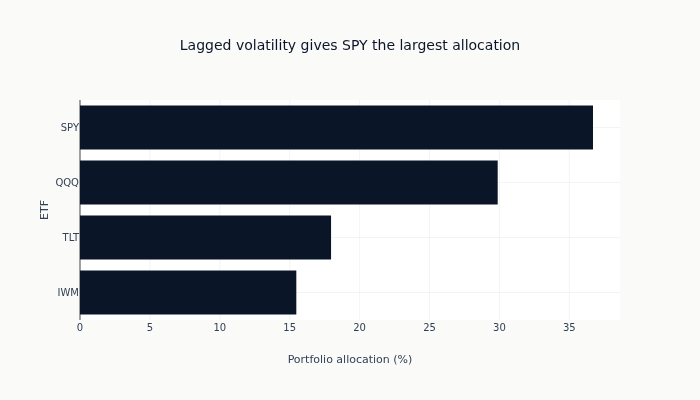

In [12]:
top_inverse_vol_symbol = inverse_volatility_df["symbol"][0]
fig = go.Figure(
    go.Bar(
        x=inverse_volatility_df["allocation_pct"],
        y=inverse_volatility_df["symbol"],
        orientation="h",
        marker_color=COLORS["blue"],
    )
)

fig.update_layout(
    title=f"Lagged volatility gives {top_inverse_vol_symbol} the largest allocation",
    xaxis_title="Portfolio allocation (%)",
    yaxis_title="ETF",
    height=400,
    yaxis={"categoryorder": "total ascending"},
)
show_plotly_with_alt(
    fig,
    "Bars of position size by stop distance, falling as the stop widens because a fixed risk budget buys fewer shares the further away the stop sits.",
)

**Interpretation**: The chart makes the ranking and budget constraint visible.
It should be read as a transparent heuristic; a covariance-aware allocator can
produce materially different weights when correlations are high.

## 4. Kelly Criterion (Cross-Reference)

Kelly sizing is covered in Chapter 17 (`04_kelly_criterion`), where it
integrates with portfolio construction. Here we focus on volatility-based
and MAE/MFE methods specific to risk management.

**Key insight**: Kelly optimizes geometric growth but requires accurate
estimates of win rate and payoff ratio. In practice, use fractional Kelly
(½ or ¼) to account for estimation error. See Chapter 17 for implementation.

## 5. Partial Exits / Scale Out

Exit positions in tranches to balance profit-taking and trend-following.

**Example Strategy**:
- Exit 1/3 at first target (lock in profits)
- Exit 1/3 at second target (capture more upside)
- Move the stop on the remainder to break-even after a target fires

Scale-out logic needs a configuration for the profit targets before we simulate
how the remaining position evolves over time.

In [13]:
@dataclass
class ScaleOutConfig:
    """Scale out (partial exit) configuration."""

    tranches: list[tuple[float, float]]  # (profit_target, exit_fraction)
    # Example: [(0.02, 0.33), (0.04, 0.33), (0.08, 0.34)]

This helper keeps the scale-out simulator compact by recording each tranche exit
in a consistent structure.

In [14]:
def _append_exit(
    exits: list[dict],
    day: int,
    price: float,
    fraction: float,
    exit_type: str,
    pnl: float,
    target: float | None = None,
) -> None:
    record = {
        "day": day,
        "price": price,
        "fraction": fraction,
        "type": exit_type,
        "pnl": pnl,
    }
    if target is not None:
        record["target"] = target
    exits.append(record)

This helper applies the tranche targets once price has moved in our favor.

In [15]:
def apply_scale_out_targets(
    config: ScaleOutConfig,
    current_return: float,
    current_price: float,
    day: int,
    remaining_position: float,
    total_return: float,
    exits: list[dict],
    executed_targets: set[int],
) -> tuple[float, float]:
    # A tranche fires on its first crossing only. Without the guard, a target that stays above its
    # level on later bars re-fires every bar and drains the position.
    for tranche_idx, (target_return, exit_fraction) in enumerate(config.tranches):
        if (
            tranche_idx in executed_targets
            or current_return < target_return
            or remaining_position <= 0
        ):
            continue
        actual_exit = min(exit_fraction, remaining_position)
        pnl = current_return * actual_exit
        total_return += pnl
        _append_exit(
            exits, day, current_price, actual_exit, "take_profit", pnl, target=target_return
        )
        remaining_position -= actual_exit
        executed_targets.add(tranche_idx)
    return remaining_position, total_return

Stop and timeout exits share the same weighted-return accounting, so a small
helper keeps that closeout invariant in one place.

In [16]:
def close_remaining_position(
    exits: list[dict],
    day: int,
    current_price: float,
    entry_price: float,
    remaining_position: float,
    exit_type: str,
) -> float:
    pnl = (current_price / entry_price - 1) * remaining_position
    _append_exit(exits, day, current_price, remaining_position, exit_type, pnl)
    return pnl

A single bar step enforces stop priority before checking the profit targets and
returns whether the position has closed.

In [17]:
def process_scale_out_bar(
    config: ScaleOutConfig,
    current_price: float,
    entry_price: float,
    day: int,
    stop_price: float,
    remaining_position: float,
    total_return: float,
    exits: list[dict],
    executed_targets: set[int],
) -> tuple[float, float, float, bool]:
    if current_price <= stop_price:
        total_return += close_remaining_position(
            exits, day, current_price, entry_price, remaining_position, "stop_loss"
        )
        return 0.0, total_return, stop_price, True

    previous_position = remaining_position
    remaining_position, total_return = apply_scale_out_targets(
        config,
        current_price / entry_price - 1,
        current_price,
        day,
        remaining_position,
        total_return,
        exits,
        executed_targets,
    )
    if remaining_position < previous_position:
        stop_price = max(stop_price, entry_price)
    return remaining_position, total_return, stop_price, False

The simulator applies a close-based stop first, then profit targets. After a target
fires, the stop ratchets once to break-even; this is not a trailing stop.

In [18]:
def simulate_scale_out(
    prices: np.ndarray,
    entry_idx: int,
    entry_price: float,
    config: ScaleOutConfig,
    stop_loss_pct: float = 0.02,
    max_holding_days: int = MAX_HOLDING_DAYS,
) -> dict:
    remaining_position, total_return = 1.0, 0.0
    exits, executed_targets = [], set()
    stop_price = entry_price * (1 - stop_loss_pct)
    final_idx = min(entry_idx + max_holding_days, len(prices) - 1)
    for i in range(entry_idx + 1, final_idx + 1):
        current_price = prices[i]
        remaining_position, total_return, stop_price, closed = process_scale_out_bar(
            config,
            current_price,
            entry_price,
            i - entry_idx,
            stop_price,
            remaining_position,
            total_return,
            exits,
            executed_targets,
        )
        if closed:
            break
    if remaining_position > 0:
        final_price = prices[final_idx]
        total_return += close_remaining_position(
            exits,
            final_idx - entry_idx,
            final_price,
            entry_price,
            remaining_position,
            "timeout",
        )
    return {"total_return": total_return, "exits": exits, "n_exits": len(exits)}

The boundary separates calibration from future evaluation. Entry candidates are
spaced beyond the longest holding period, and a 30-bar embargo follows the boundary.

In [19]:
spy_prices = close_prices["SPY"].to_numpy()
calibration_end_idx = (
    close_prices.index.searchsorted(pd.Timestamp(CALIBRATION_END), side="right") - 1
)
future_start_idx = calibration_end_idx + MAX_HOLDING_DAYS + 1
entry_spacing = MAX_HOLDING_DAYS + 1

calibration_entry_indices = np.arange(
    50,
    calibration_end_idx - MAX_HOLDING_DAYS + 1,
    entry_spacing,
)
future_entry_indices = np.arange(
    future_start_idx,
    len(spy_prices) - MAX_HOLDING_DAYS,
    entry_spacing,
)
assert calibration_entry_indices[-1] + MAX_HOLDING_DAYS <= calibration_end_idx
assert future_entry_indices[0] > calibration_end_idx + MAX_HOLDING_DAYS
print(
    f"Calibration entries: {len(calibration_entry_indices)} through {CALIBRATION_END}; "
    f"future entries: {len(future_entry_indices)} after a {MAX_HOLDING_DAYS}-bar embargo"
)

Calibration entries: 30 through 2021-12-31; future entries: 15 after a 30-bar embargo


This helper applies one fixed exit policy to a supplied entry set, keeping the
calibration and future samples explicit at the call site.

In [20]:
def simulate_entry_set(
    prices: np.ndarray,
    entries: np.ndarray,
    config: ScaleOutConfig,
) -> list[float]:
    return [
        simulate_scale_out(
            prices,
            entry_idx,
            prices[entry_idx],
            config,
            stop_loss_pct=0.02,
        )["total_return"]
        for entry_idx in entries
    ]

In [21]:
full_exit_config = ScaleOutConfig(tranches=[(0.03, 1.0)])
scale_out_config = ScaleOutConfig(tranches=[(0.02, 0.33), (0.04, 0.33), (0.08, 0.34)])
full_exit_returns = simulate_entry_set(spy_prices, future_entry_indices, full_exit_config)
scale_out_returns = simulate_entry_set(spy_prices, future_entry_indices, scale_out_config)

In [22]:
exit_comparison = pl.DataFrame(
    {
        "policy": ["Full exit", "Scale out"],
        "mean_return_pct": [np.mean(full_exit_returns) * 100, np.mean(scale_out_returns) * 100],
        "std_return_pct": [np.std(full_exit_returns) * 100, np.std(scale_out_returns) * 100],
        "win_rate_pct": [
            np.mean(np.array(full_exit_returns) > 0) * 100,
            np.mean(np.array(scale_out_returns) > 0) * 100,
        ],
        "future_trades": [len(full_exit_returns), len(scale_out_returns)],
    }
)
exit_comparison

policy,mean_return_pct,std_return_pct,win_rate_pct,future_trades
str,f64,f64,f64,i64
"""Full exit""",0.289334,2.904321,46.666667,15
"""Scale out""",0.629359,3.275282,46.666667,15


**Interpretation**: The future-sample table reports the trade-off without assuming
that partial exits smooth returns. The common, non-overlapping entry set isolates
exit-policy differences, while the small sample remains a limitation.

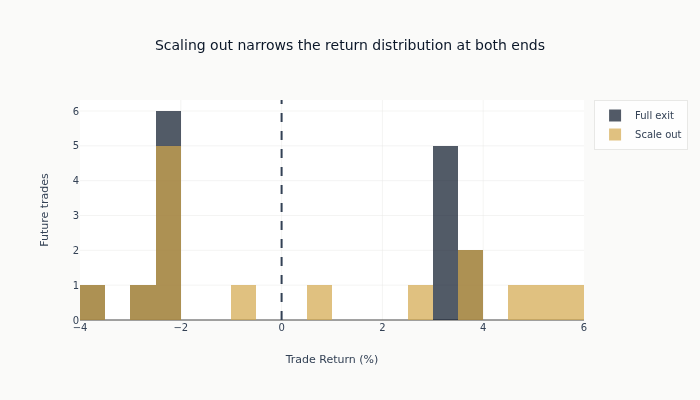

In [23]:
# Visualize return distributions
fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=np.array(full_exit_returns) * 100,
        name="Full exit",
        opacity=0.7,
        nbinsx=20,
        marker_color=COLORS["blue"],
    )
)

fig.add_trace(
    go.Histogram(
        x=np.array(scale_out_returns) * 100,
        name="Scale out",
        opacity=0.7,
        nbinsx=20,
        marker_color=COLORS["amber"],
    )
)

full_exit_mean = np.mean(full_exit_returns) * 100
scale_out_mean = np.mean(scale_out_returns) * 100
leading_policy = "Full exits" if full_exit_mean >= scale_out_mean else "Scale-outs"
mean_return_gap = abs(full_exit_mean - scale_out_mean)
fig.update_layout(
    title="Scaling out narrows the return distribution at both ends",
    xaxis_title="Trade Return (%)",
    yaxis_title="Future trades",
    barmode="overlay",
    height=400,
)
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])
show_plotly_with_alt(
    fig,
    "Bars of inverse-volatility weight per ETF, tallest for the least volatile fund and shortest for the most volatile.",
)

**Interpretation**: The zero line and common bins show whether the policy changes
downside mass or mainly gives up upside. The computed title records the observed
mean difference without hardcoding a result that can drift after execution.

## 6. MAE/MFE Analysis

**MAE (Maximum Adverse Excursion)**: Largest drawdown during a trade
**MFE (Maximum Favorable Excursion)**: Largest gain during a trade

MAE/MFE analysis describes realized paths and supplies calibration evidence; it
does not identify a financially optimal stop without a PnL objective.

In [24]:
def calculate_mae_mfe(
    lows: np.ndarray,
    highs: np.ndarray,
    entry_idx: int,
    exit_idx: int,
    entry_price: float,
) -> dict:
    """
    Calculate MAE and MFE for a trade.

    MAE: Maximum adverse excursion (worst drawdown during trade)
    MFE: Maximum favorable excursion (best gain during trade)
    """
    if exit_idx <= entry_idx:
        return {"mae": 0, "mfe": 0, "mae_pct": 0, "mfe_pct": 0}

    # A close entry cannot experience the entry bar's earlier high or low.
    trade_lows = lows[entry_idx + 1 : exit_idx + 1]
    trade_highs = highs[entry_idx + 1 : exit_idx + 1]

    lowest_price = trade_lows.min()
    highest_price = trade_highs.max()

    mae = min(0.0, (lowest_price - entry_price) / entry_price)
    mfe = max(0.0, (highest_price - entry_price) / entry_price)

    return {
        "mae": mae,
        "mfe": mfe,
        "mae_pct": mae * 100,
        "mfe_pct": mfe * 100,
        "lowest_price": lowest_price,
        "highest_price": highest_price,
    }

The trade builder keeps the calibration and future entry sets separate and
records entry/exit timestamps so every statistic is traceable to its split.

In [25]:
def build_trade_excursions(
    entries: np.ndarray,
    split: str,
    prices: np.ndarray,
    lows: np.ndarray,
    highs: np.ndarray,
    timestamps: pd.DatetimeIndex,
) -> pl.DataFrame:
    records = []
    for entry_idx in entries:
        exit_idx = entry_idx + HOLDING_PERIOD
        entry_price = prices[entry_idx]
        result = calculate_mae_mfe(lows, highs, entry_idx, exit_idx, entry_price)
        trade_return = (prices[exit_idx] / entry_price - 1) * 100
        records.append(
            {
                "split": split,
                "entry_timestamp": timestamps[entry_idx],
                "exit_timestamp": timestamps[exit_idx],
                "mae_pct": result["mae_pct"],
                "mfe_pct": result["mfe_pct"],
                "trade_return": trade_return,
                "is_winner": bool(trade_return > 0),
            }
        )
    return pl.DataFrame(records)

In [26]:
spy_lows = low_prices["SPY"].values
spy_highs = high_prices["SPY"].values
mae_mfe_df = pl.concat(
    [
        build_trade_excursions(
            calibration_entry_indices,
            "calibration",
            spy_prices,
            spy_lows,
            spy_highs,
            close_prices.index,
        ),
        build_trade_excursions(
            future_entry_indices,
            "future",
            spy_prices,
            spy_lows,
            spy_highs,
            close_prices.index,
        ),
    ]
)

# Persist MAE/MFE trade-level data for the figure-19.8 publication script (left panel).
mae_mfe_df.write_parquet(OUTPUT_DIR / "mae_mfe_trades.parquet")

In [27]:
excursion_summary = (
    mae_mfe_df.with_columns(
        outcome=pl.when("is_winner").then(pl.lit("Winner")).otherwise(pl.lit("Loser"))
    )
    .group_by(["split", "outcome"])
    .agg(
        trades=pl.len(),
        avg_mae_pct=pl.col("mae_pct").mean(),
        avg_mfe_pct=pl.col("mfe_pct").mean(),
        avg_return_pct=pl.col("trade_return").mean(),
    )
    .sort(["split", "outcome"])
)
excursion_summary

split,outcome,trades,avg_mae_pct,avg_mfe_pct,avg_return_pct
str,str,u32,f64,f64,f64
"""calibration""","""Loser""",12,-6.827296,1.94203,-2.964211
"""calibration""","""Winner""",18,-2.086663,3.8024,3.165841
"""future""","""Loser""",8,-5.975059,1.940035,-4.343012
"""future""","""Winner""",7,-1.56522,5.732962,4.781823


**Interpretation**: The split-specific table shows whether the calibration pattern
holds on trades the calibration never saw. MAE/MFE remains a post-hoc diagnostic: the future
outcome label organizes the evidence but never enters a pre-trade feature.

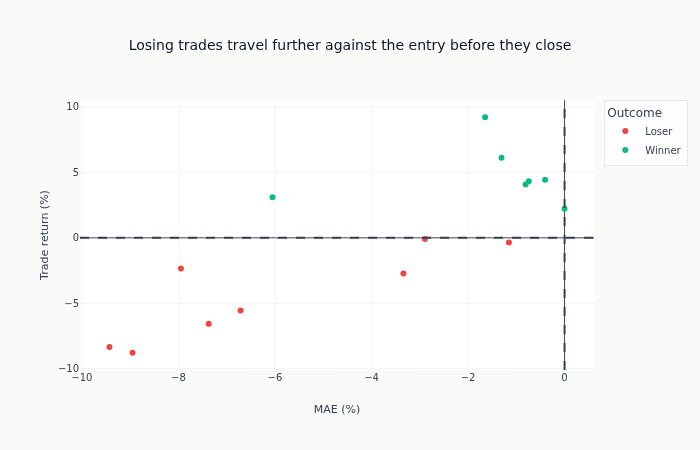

In [28]:
future_excursions = mae_mfe_df.filter(pl.col("split") == "future").with_columns(
    outcome=pl.when("is_winner").then(pl.lit("Winner")).otherwise(pl.lit("Loser"))
)
future_excursions_pd = future_excursions.to_pandas()
future_mae_by_outcome = future_excursions.group_by("outcome").agg(pl.col("mae_pct").mean())
future_mae_gap = abs(
    future_mae_by_outcome.filter(pl.col("outcome") == "Loser")["mae_pct"][0]
) - abs(future_mae_by_outcome.filter(pl.col("outcome") == "Winner")["mae_pct"][0])

fig = px.scatter(
    future_excursions_pd,
    x="mae_pct",
    y="trade_return",
    color="outcome",
    color_discrete_map={"Winner": COLORS["positive"], "Loser": COLORS["negative"]},
    title="Losing trades travel further against the entry before they close",
    labels={"mae_pct": "MAE (%)", "trade_return": "Trade return (%)", "outcome": "Outcome"},
)

fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])

fig.update_layout(height=450)
show_plotly_with_alt(
    fig,
    "Two return distributions on shared axes, full exits against scale-outs. The scale-out distribution is narrower at both ends.",
)

**Interpretation**: The future scatter tests whether adverse excursion remains
associated with the realized outcome after calibration. It does not imply that a
stop at any particular MAE would improve PnL.

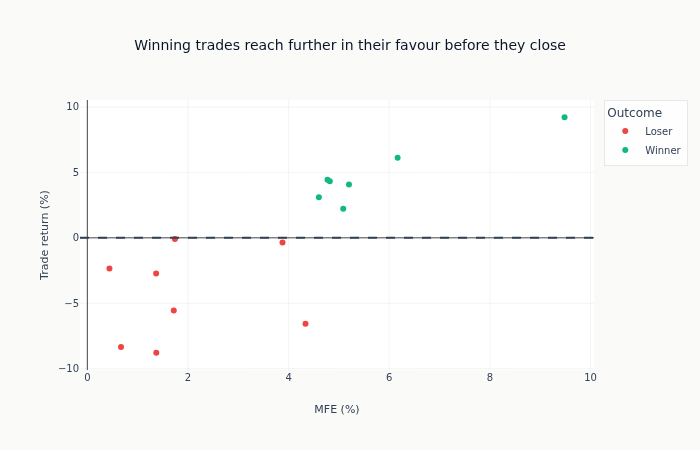

In [29]:
future_mfe_by_outcome = future_excursions.group_by("outcome").agg(pl.col("mfe_pct").mean())
future_mfe_gap = (
    future_mfe_by_outcome.filter(pl.col("outcome") == "Winner")["mfe_pct"][0]
    - (future_mfe_by_outcome.filter(pl.col("outcome") == "Loser")["mfe_pct"][0])
)
fig = px.scatter(
    future_excursions_pd,
    x="mfe_pct",
    y="trade_return",
    color="outcome",
    color_discrete_map={"Winner": COLORS["positive"], "Loser": COLORS["negative"]},
    title="Winning trades reach further in their favour before they close",
    labels={"mfe_pct": "MFE (%)", "trade_return": "Trade return (%)", "outcome": "Outcome"},
)

fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])

fig.update_layout(height=450)
show_plotly_with_alt(
    fig,
    "A scatter of trade return against maximum adverse excursion, coloured by outcome. Losing trades cluster at deeper adverse excursions and the two groups overlap substantially in the middle.",
)

**Interpretation**: The favorable-excursion gap describes the future sample. It
can inform a take-profit prior, but a deployable threshold still needs a frozen
PnL objective and cost-aware forward evaluation.

### Choosing a Stop Distance from Adverse Excursions

A stop distance is worth setting where the trades that end badly have already travelled past it
and the trades that end well mostly have not. For each candidate distance, the code below counts
the share of eventually-losing trades whose worst excursion breached it, and the share of
eventually-profitable trades that also breached it. The difference between those two shares says
how much the distance discriminates.

What that difference is not is a profit. It counts breaches, not the money a stop would have
saved or the gains it would have cut short, and a distance that discriminates well can still lose
money once execution is priced. The distance is chosen on the calibration trades and then frozen,
so the future column is a test rather than a second look.

In [30]:
def analyze_stop_separation(
    excursions: pl.DataFrame,
    stop_distances: np.ndarray,
    split: str,
) -> pl.DataFrame:
    """Compare loser and winner breach rates across stop distances."""
    results = []
    losers = excursions.filter(~pl.col("is_winner"))
    winners = excursions.filter(pl.col("is_winner"))
    if losers.is_empty() or winners.is_empty():
        raise ValueError(f"{split} needs both winners and losers")
    for distance in stop_distances:
        loser_rate = losers.select((pl.col("mae_pct") <= -distance).mean()).item() * 100
        winner_rate = winners.select((pl.col("mae_pct") <= -distance).mean()).item() * 100
        results.append(
            {
                "split": split,
                "stop_distance_pct": distance,
                "loser_breach_rate_pct": loser_rate,
                "winner_breach_rate_pct": winner_rate,
                "separation_score_pct": loser_rate - winner_rate,
            }
        )
    return pl.DataFrame(results)

In [31]:
stop_distances = np.linspace(0.5, 5.0, 20)
calibration_stop_curve = analyze_stop_separation(
    mae_mfe_df.filter(pl.col("split") == "calibration"), stop_distances, "calibration"
)
future_stop_curve = analyze_stop_separation(
    mae_mfe_df.filter(pl.col("split") == "future"), stop_distances, "future"
)
stop_analysis = pl.concat([calibration_stop_curve, future_stop_curve])
selected_stop_distance = calibration_stop_curve.sort("separation_score_pct", descending=True)[
    "stop_distance_pct"
][0]
threshold_summary = stop_analysis.filter(
    pl.col("stop_distance_pct") == selected_stop_distance
).sort("split")
stop_analysis.write_parquet(OUTPUT_DIR / "stop_calibration_tradeoff.parquet")
threshold_summary

split,stop_distance_pct,loser_breach_rate_pct,winner_breach_rate_pct,separation_score_pct
str,f64,f64,f64,f64
"""calibration""",3.578947,75.0,11.111111,63.888889
"""future""",3.578947,62.5,14.285714,48.214286


**Interpretation**: The first row is the distance that discriminated best on the calibration
trades. The second applies that same distance, unchanged, to trades from a later period. If the
two rows are close, the distance describes something about how this instrument moves rather than
something about the particular trades it was chosen on. Neither row prices the stop.

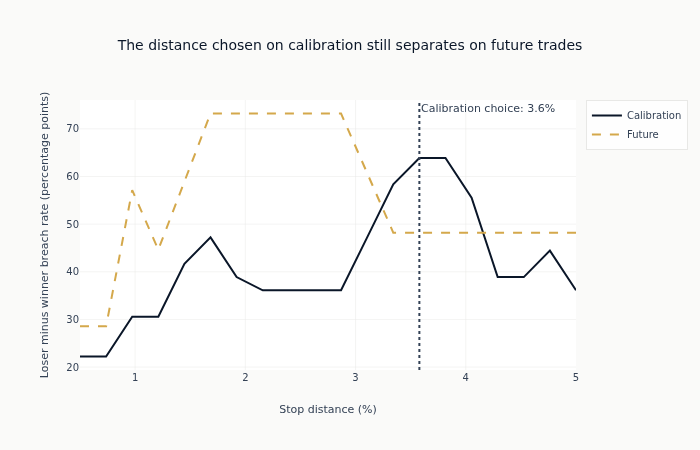

In [32]:
fig = go.Figure()
_ = fig.add_trace(
    go.Scatter(
        x=calibration_stop_curve["stop_distance_pct"],
        y=calibration_stop_curve["separation_score_pct"],
        name="Calibration",
        line={"color": COLORS["blue"], "width": 2},
    )
)
_ = fig.add_trace(
    go.Scatter(
        x=future_stop_curve["stop_distance_pct"],
        y=future_stop_curve["separation_score_pct"],
        name="Future",
        line={"color": COLORS["amber"], "width": 2, "dash": "dash"},
    )
)
future_selected_score = threshold_summary.filter(pl.col("split") == "future")[
    "separation_score_pct"
][0]
fig.add_vline(
    x=selected_stop_distance,
    line_dash="dot",
    line_color=COLORS["neutral"],
    annotation_text=f"Calibration choice: {selected_stop_distance:.1f}%",
)
fig.update_layout(
    title="The distance chosen on calibration still separates on future trades",
    xaxis_title="Stop distance (%)",
    yaxis_title="Loser minus winner breach rate (percentage points)",
    height=450,
)
show_plotly_with_alt(
    fig,
    "A scatter of trade return against maximum favorable excursion, coloured by outcome. Winning trades reach further in their favour, with overlap near the origin.",
)

**Interpretation**: A stable future separation supports the threshold as a
diagnostic prior, not as an executable optimum. A cost-aware stop simulation is
still required before the distance can be judged by return or utility.

### Excursion Percentiles by Horizon

The trade-level MAE/MFE analysis above uses intraday highs and lows for specified
entries. The complementary close-path distribution uses only bars after a close
entry and estimates its percentiles on the calibration window. The future window
tests whether those descriptive priors remain representative.

The builder records horizon-specific adverse and favorable close-path excursions.
It excludes the entry bar, matching the close-entry event order used above.

In [33]:
def build_excursion_percentiles(
    prices: np.ndarray,
    horizons: list[int],
    split: str,
) -> pl.DataFrame:
    rows = []
    for horizon in horizons:
        adverse = []
        favorable = []
        for entry_idx in range(len(prices) - horizon):
            future_path = prices[entry_idx + 1 : entry_idx + horizon + 1] / prices[entry_idx] - 1
            adverse.append(min(0.0, float(future_path.min())))
            favorable.append(max(0.0, float(future_path.max())))
        for side, values in [("mae", adverse), ("mfe", favorable)]:
            rows.append(
                {
                    "split": split,
                    "horizon": horizon,
                    "side": side,
                    **{
                        f"p{percentile}": np.percentile(values, percentile)
                        for percentile in [10, 25, 50, 75, 90]
                    },
                }
            )
    return pl.DataFrame(rows)

In [34]:
horizons = [10, 20, 40, 60]
calibration_prices = spy_prices[: calibration_end_idx + 1]
future_prices = spy_prices[future_start_idx:]
calibration_percentiles = build_excursion_percentiles(calibration_prices, horizons, "calibration")
future_percentiles = build_excursion_percentiles(future_prices, horizons, "future")
excursion_percentiles = pl.concat([calibration_percentiles, future_percentiles])

In [35]:
level_rows = []
for horizon in [20, 40, 60]:
    for split in ["calibration", "future"]:
        subset = excursion_percentiles.filter(
            (pl.col("split") == split) & (pl.col("horizon") == horizon)
        )
        level_rows.append(
            {
                "split": split,
                "horizon": horizon,
                "mae_p25_pct": subset.filter(pl.col("side") == "mae")["p25"][0] * 100,
                "mfe_p75_pct": subset.filter(pl.col("side") == "mfe")["p75"][0] * 100,
            }
        )
excursion_level_df = pl.DataFrame(level_rows).sort(["horizon", "split"])
excursion_level_df

split,horizon,mae_p25_pct,mfe_p75_pct
str,i64,f64,f64
"""calibration""",20,-3.628201,4.626413
"""future""",20,-5.145573,5.386044
"""calibration""",40,-4.745305,6.988812
"""future""",40,-7.184645,8.03898
"""calibration""",60,-5.404292,9.34077
"""future""",60,-8.527643,9.805733


**Interpretation**: Calibration levels are historical priors, not labels attached
to the current bar. The future rows reveal distribution drift and prevent a
full-sample percentile from being presented as a pre-trade rule.

In [36]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Favorable excursion", "Adverse excursion"],
    horizontal_spacing=0.12,
)
percentile_colors = dict(zip(["p25", "p50", "p75"], ml4t_palette(3, categorical=True), strict=True))
for col_idx, side in [(1, "mfe"), (2, "mae")]:
    for percentile, color in percentile_colors.items():
        for split, dash in [("calibration", "solid"), ("future", "dash")]:
            subset = excursion_percentiles.filter(
                (pl.col("split") == split) & (pl.col("side") == side)
            ).sort("horizon")
            fig.add_scatter(
                x=subset["horizon"],
                y=subset[percentile] * 100,
                name=f"{percentile.upper()} {split}",
                mode="lines+markers",
                line={"color": color, "dash": dash},
                legendgroup=f"{percentile}-{split}",
                showlegend=col_idx == 1,
                row=1,
                col=col_idx,
            )

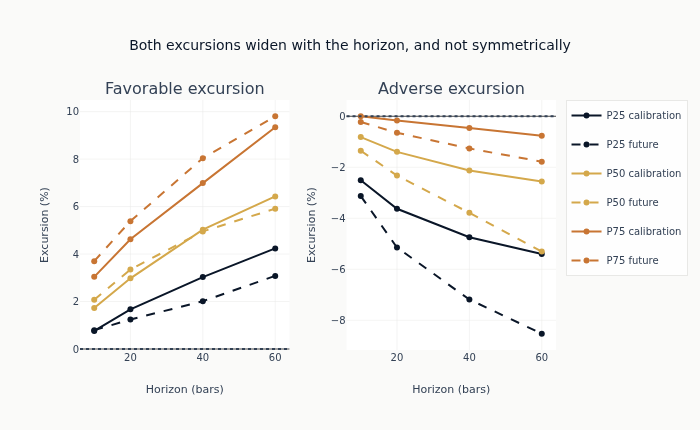

In [37]:
future_60 = excursion_level_df.filter(
    (pl.col("split") == "future") & (pl.col("horizon") == 60)
).row(0, named=True)
fig.update_xaxes(title_text="Horizon (bars)")
fig.update_yaxes(title_text="Excursion (%)")
fig.add_hline(y=0, line_dash="dot", line_color=COLORS["neutral"])
fig.update_layout(
    title="Both excursions widen with the horizon, and not symmetrically",
    height=430,
)
show_plotly_with_alt(
    fig,
    "Two curves of separation score against stop distance, calibration and future, with a dotted line at the distance chosen on calibration. Both rise to a broad maximum and the future curve is the noisier of the two.",
)

**Interpretation**: Solid calibration curves and dashed future curves make the
stability test visible. A strategy may use the calibration quantiles as starting
values, but it still needs a cost-aware PnL objective before deployment.

**Trade-level vs path-level analysis**:

| Aspect | Trade MAE/MFE | Close-path percentiles |
|---|---|---|
| Purpose | Post-hoc trade diagnostics | Horizon-conditioned historical priors |
| Input | Entry, exit, future highs/lows | Close paths after a close entry |
| Output | Per-trade MAE/MFE | Calibration and future percentile matrices |
| Use | Explain realized trade paths | Test whether threshold priors remain stable |

Neither diagnostic establishes stop-policy value without explicit execution,
transaction-cost, and PnL conventions.

## 7. Dynamic Position Sizing Based on Conviction

Adjust position size based on signal strength or conviction score.

In [38]:
def calculate_conviction_based_size(
    base_position_pct: float,
    conviction_score: float,  # 0 to 1
    min_multiplier: float = 0.2,
    max_multiplier: float = 2.0,
) -> float:
    """
    Scale position size by conviction.

    Position = base × (min_multiplier + conviction × (max_multiplier - min_multiplier))
    """
    if base_position_pct < 0:
        raise ValueError("base_position_pct must be nonnegative")
    if not 0 <= conviction_score <= 1:
        raise ValueError("conviction_score must lie in [0, 1]")
    if min_multiplier < 0 or max_multiplier < min_multiplier:
        raise ValueError("multipliers must be ordered and nonnegative")
    multiplier = min_multiplier + conviction_score * (max_multiplier - min_multiplier)
    return base_position_pct * multiplier

In [39]:
# Example: Conviction-based sizing
conviction_scores = np.linspace(0, 1, 11)
base_pct = 0.05

conviction_sizing_df = pl.DataFrame(
    {
        "conviction": conviction_scores,
        "position_pct": [calculate_conviction_based_size(base_pct, c) for c in conviction_scores],
    }
)

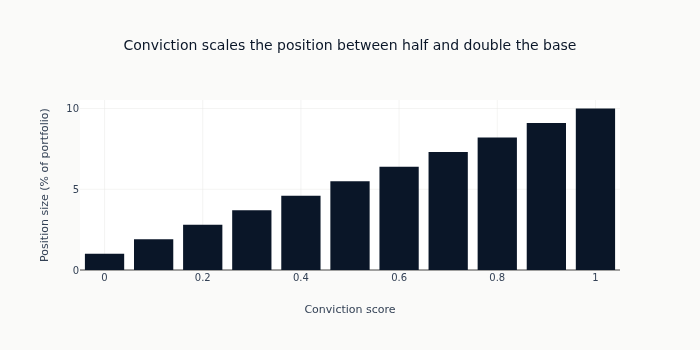

In [40]:
fig = go.Figure(
    go.Bar(
        x=conviction_sizing_df["conviction"],
        y=conviction_sizing_df["position_pct"] * 100,
        marker_color=COLORS["blue"],
    )
)
fig.update_layout(
    title="Conviction scales the position between half and double the base",
    xaxis_title="Conviction score",
    yaxis_title="Position size (% of portfolio)",
    height=350,
)
show_plotly_with_alt(
    fig,
    "Excursion percentile bands widening with the holding horizon, favorable above zero and adverse below, with the adverse side widening faster.",
)

**Interpretation**: The mapping is a deterministic function of the score, bounded above and
below so that no single conviction reading can concentrate the book. What it cannot supply is
the score. A conviction number that has not been shown to relate to realized outcomes will size
positions confidently in the wrong direction, and the bounds are what limit the damage.

## 8. Conformal Prediction Intervals and Position Sizing

Conformal prediction (Chapter 11) produces calibrated uncertainty intervals
for return forecasts. Wider intervals can motivate smaller allocations, but the
interval provenance and calibration boundary are part of the sizing contract.

**Concept**: Scale position inversely to conformal interval width:

$$w_t = w_{\text{base}} \times \frac{\Delta_{\text{median}}}{\Delta_t}$$

where $\Delta_t$ is the conformal interval width at time $t$.

See Chapter 17 (`07_conformal_position_sizing`) for the versioned implementation and
its data contract. This notebook deliberately does not load a case-study prediction
artifact: an opaque or unavailable conformal run cannot support a teaching result.

## 9. Key Takeaways

1. **Size a position from the loss you will accept, not the gain you hope for.** Fixed-fractional
   sizing starts from a stop distance and a risk budget and solves for the share count. That
   ordering is what makes the risk per trade a decision rather than a consequence.

2. **Round to whole shares before reporting the risk.** The share count that can actually be sent
   is an integer, and rounding it changes both the position's value and the loss the stop would
   realize. Reporting the unrounded figure overstates how precisely the risk budget was hit.

3. **Name a sizing heuristic by what it does.** Weighting by the inverse of each asset's own
   volatility equalizes standalone risk contributions and ignores the correlations between them.
   That is a different thing from risk parity, and calling it risk parity implies a covariance
   calculation nobody performed.

4. **Lag every input to an adaptive control.** A weight dated to a session must be computed from
   a window ending the session before, because the session's own volatility is not known until it
   has closed.

5. **Measure excursions from the bar after entry.** A position opened at the close cannot
   experience that bar's earlier high or low, and including them inflates both excursions and
   makes every stop look more likely to have been hit than it was.

6. **Separation is not profit.** Counting how much more often losing trades breach a distance
   than winning ones says whether the distance discriminates. It says nothing about what
   executing the stop would have earned or cost, which needs the trades re-run with the rule
   applied and its costs charged.

7. **Choose a threshold on one window and test it on a later one.** Reporting the distance that
   scored best on the trades used to pick it is not evidence about anything. The value of the
   calibration-then-future structure here is that the second column can disappoint.

### Known limitations

- The excursion analysis runs on one symbol from a four-ETF panel, over one calibration window
  and one future window. A single future window can agree with the calibration by chance.
- Trades are opened on a fixed schedule and held for a fixed number of sessions, so the
  excursion distributions describe holding periods rather than a strategy's actual trades.
- No cost is charged anywhere in this notebook. A scale-out policy that exits in three tranches
  pays three times the fixed costs of a single exit, which is enough to reverse the comparison in
  Section 5 at realistic cost levels.
- The conviction mapping is a stated function of a score the notebook does not produce or
  validate. It bounds the position; it does not make the score informative.
- Inverse-volatility weights use a trailing window and are reported at one date, so they show the
  construction rather than how the allocation would have turned over.

**Next**: [`04_factor_exposure`](04_factor_exposure.ipynb) asks what a portfolio sized this way is
actually exposed to, which is a different question from how much of it to hold.